[Exemplos no site gmsh ](https://gmsh.info/doc/texinfo/gmsh.html#Geometry-module) \
[Exemplos do firedrakeproject.org](https://www.firedrakeproject.org/demos/immersed_fem.py.html) 

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
from IPython.display import Image
import firedrake as fd
from firedrake import PointEvaluator
from firedrake.output import VTKFile
import gmsh
import matplotlib.pyplot as plt
import csv
import pandas as pd

Abaixo vamos importar a malha do gmesh. O gmsh gera um arquivo ".geo" \

gmsh mesh.geo -2 -o mesh.msh \
-2 é a dimensão da malha 


In [2]:
# Finite element mesh
# Nx, Ny = 16, 16
# Lx, Ly = 1.0, 1.0
# msh = fd.RectangleMesh(Nx, Ny, Lx, Ly, quadrilateral=True)
#msh = fd.Mesh('mesh.msh')
os.makedirs("resultados", exist_ok=True)
resultados = []
for N in [16, 32, 64, 128]:
    Lx, Ly = 1.0, 1.0
    msh = fd.RectangleMesh(N, N, Lx, Ly, quadrilateral=True)
    
    # Space of functions
    Vd = fd.FunctionSpace(msh, "CG", degree=1)
    Vstress = fd.FunctionSpace(msh, "DG", degree=0)
    
    # Test and Trial functions
    u  = fd.TrialFunction(Vd)
    v  = fd.TestFunction(Vd)
    # Boundary conditions
    u_boundary = fd.Constant(0.0)
    bc = fd.DirichletBC(Vd, u_boundary, "on_boundary")
    
    # Exemplo de Dirichlet zero nas paredes e valor 1 no obstáculo
    bc_paredes = fd.DirichletBC(Vd, fd.Constant(0.0), 10)
    bc_obstaculo = fd.DirichletBC(Vd, fd.Constant(1.0), 11)
    
    # Junta as condições de contorno para o solver
    bcs = [bc_paredes, bc_obstaculo]
    # Source term
    f  = fd.Constant(1.0)
    
    x  = fd.SpatialCoordinate(msh) #acess the physical spatial coordinates from the mesh
    #mu = fd.Constant(1.0) # this could be a function of x
    mu = 0.01 + fd.exp(-100 * ((x[0] - 0.5)**2 + (x[1] - 0.5)**2))
    
    # Bilinear form (lhs) and linear form (rhs)
    a  = fd.inner(mu * fd.grad(u), fd.grad(v)) * fd.dx
    L  = fd.inner(f, v) * fd.dx
    
    # Solve the problem
    ud = fd.Function(Vd)
    problem = fd.LinearVariationalProblem(a, L, ud, bcs=bc)
    opts={"ksp_type": "preonly", "pc_type": "lu"}
    solver = fd.LinearVariationalSolver(problem, solver_parameters=opts)
    solver.solve()
    
    # Shear Stress and Boundary Integration
    tau = mu * fd.grad(ud)
    n   = fd.FacetNormal(msh)
    Wss = fd.inner(tau, n) * fd.ds
    
    #print(fd.assemble(Wss))
    
    # Visualize in paraview
    ud.rename = "mySolution"
    VTKFile(f"SolPoisson_{N}.pvd").write(ud)
    
    u_max     = float(ud.dat.data_ro.max())
    norma_L2  = float(fd.norm(ud, norm_type="L2"))
    Wss_value = float(fd.assemble(Wss))
    num_celulas  = msh.num_cells()
    num_vertices = msh.num_vertices()
    num_dofs     = Vd.dim()
    resultados.append({
        "N": N,
        "celulas": num_celulas,
        "vertices": num_vertices,
        "dofs": num_dofs,
        "u_max": u_max,
        "norma_L2": norma_L2,
        "Wss": Wss_value
    })

In [3]:
with open("resultados/resumo_numerico.csv", "w", newline="") as arquivo:
    colunas = ["N","celulas","vertices", "dofs", "u_max","norma_L2","Wss"]
    escritor = csv.DictWriter(arquivo, fieldnames=colunas)
    escritor.writeheader()
    escritor.writerows(resultados)

## Resultados para a malha triangular

In [4]:
df = pd.read_csv("resultados/resumo_numerico_triangular.csv")
print(df)

     N  celulas  vertices   dofs     u_max  norma_L2       Wss
0   16      512       289    289  6.115742  3.912378 -0.878906
1   32     2048      1089   1089  6.188004  3.956029 -0.938477
2   64     8192      4225   4225  6.206582  3.967004 -0.968994
3  128    32768     16641  16641  6.211268  3.969756 -0.984436


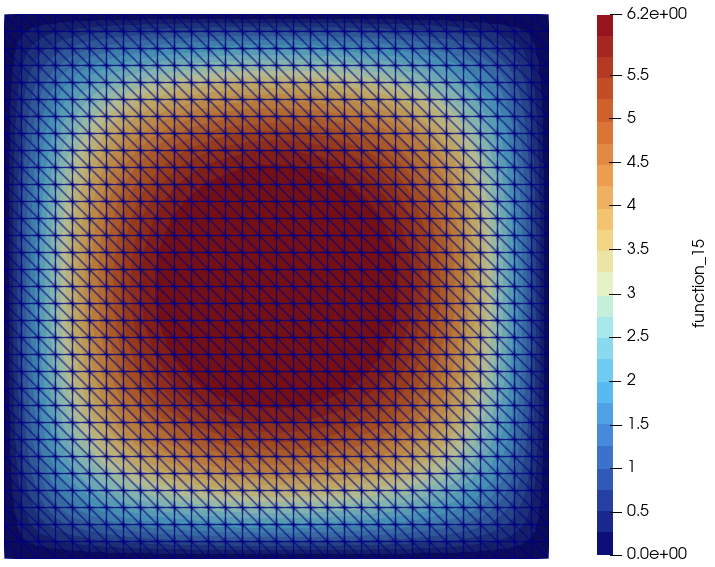

In [5]:
Image(filename='/home/victorcunha/Documentos/repository/ef_firedrake/ef/Figuras/triangular_32.png', width=400) 

In [6]:
df = pd.read_csv("resultados/resumo_numerico_quadrangular.csv")
print(df)

     N  celulas  vertices   dofs     u_max  norma_L2       Wss
0   16      256       289    289  6.163372  3.942075 -0.887435
1   32     1024      1089   1089  6.200374  3.963580 -0.941183
2   64     4096      4225   4225  6.209704  3.968900 -0.969814
3  128    16384     16641  16641  6.212051  3.970230 -0.984677


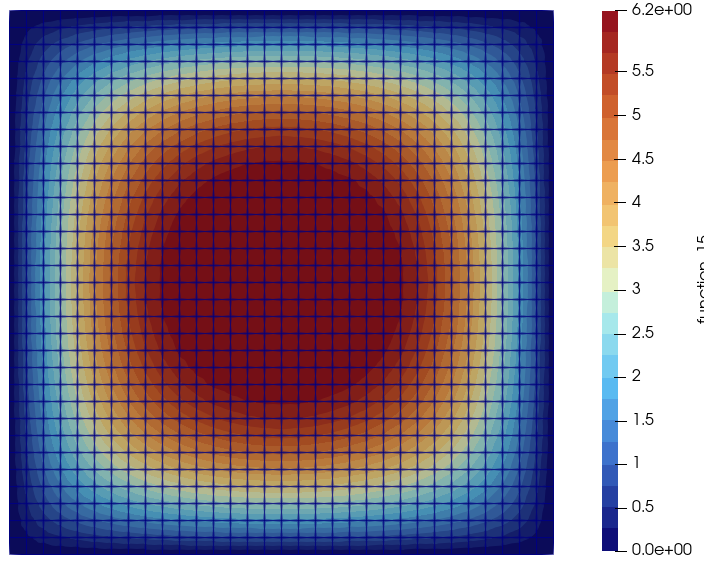

In [7]:
Image(filename='/home/victorcunha/Documentos/repository/ef_firedrake/ef/Figuras/quadrangular_32.png', width=400) 

The numerical results show a consistent stabilization of the solution
under mesh refinement. The value at the center of the domain increases
from $6.115742$ on the $16\times16$ mesh to $6.211268$ on the
$128\times128$ mesh. At the same time, the relative variation between
consecutive meshes decreases from approximately $1.168\%$ to
$0.075\%$.

A similar behavior is observed for the $L^2$ norm of the solution.
Its relative variation decreases from approximately $1.103\%$ between
the $16\times16$ and $32\times32$ meshes to only $0.069\%$ between
the $64\times64$ and $128\times128$ meshes. These results indicate
that the numerical solution is approaching mesh independence.

For all mesh resolutions, the maximum numerical value is attained at
the center of the domain. This result is consistent with the symmetry
of the domain, the coefficient $\mu(\mathbf{x})$, the source term, and
the homogeneous Dirichlet boundary conditions.

The boundary integral $W_{ss}$ approaches the expected value $-1$ as
the mesh is refined. Its relative error decreases from approximately
$12.109\%$ on the coarsest mesh to $1.556\%$ on the finest mesh. The
error is approximately divided by two at each refinement, suggesting
first-order convergence for the boundary flux recovered from the
gradient of the $CG1$ finite element solution.

## Cálculo da magnitude

In [11]:
tau_magnitude_expression = fd.sqrt(fd.inner(tau, tau))
tau_magnitude = fd.Function(Vstress, name="magnitude_tau") # Interpolação no espaço DG0
tau_magnitude.interpolate(tau_magnitude_expression)
arquivo_vtk = VTKFile(f"resultados/campos_N{N}.pvd")
arquivo_vtk.write(ud, tau_magnitude)

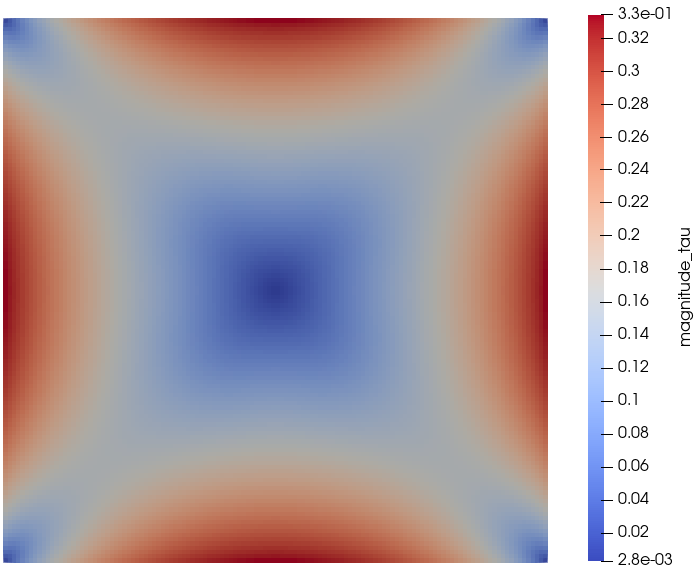

In [13]:
Image(filename='/home/victorcunha/Documentos/repository/ef_firedrake/ef/Figuras/magnitude.png', width=200) 

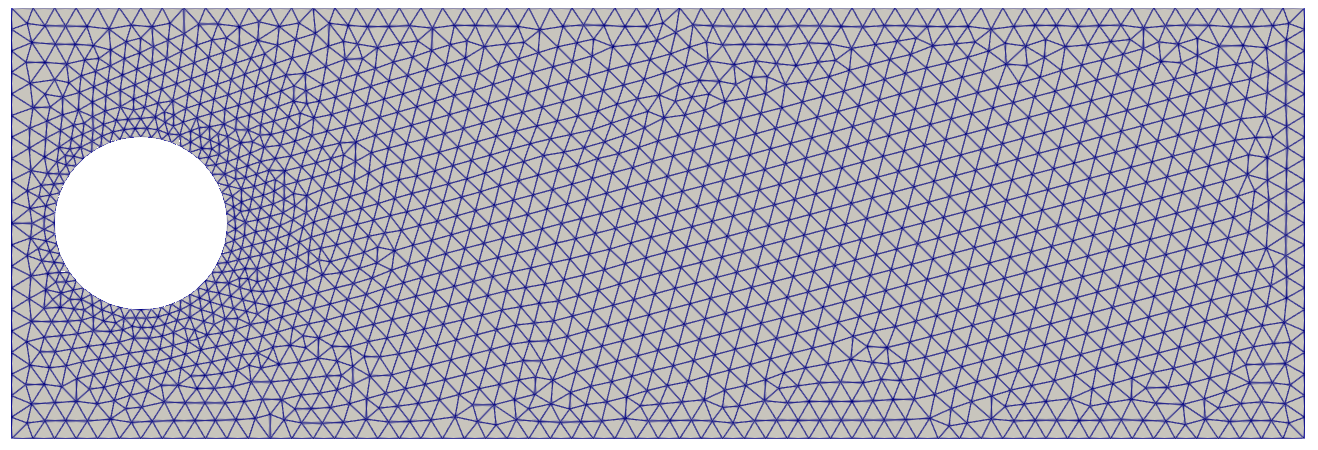

In [9]:
Image(filename='/home/victorcunha/Documentos/repository/ef_firedrake/ef/Figuras/mesh_hole.png', width=600)

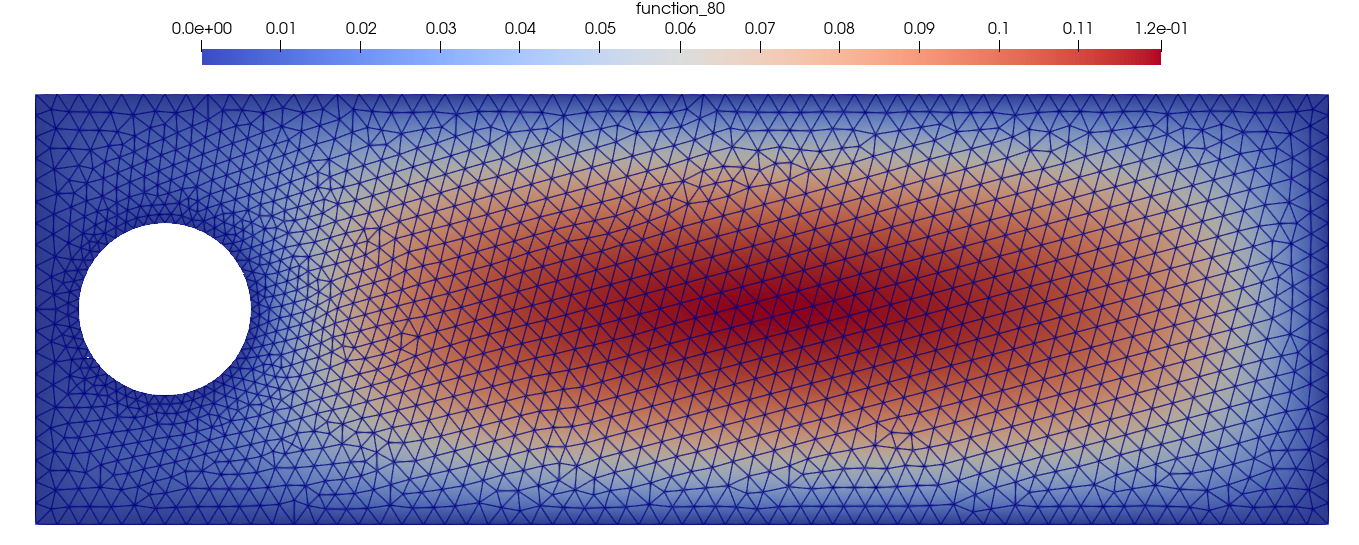

In [8]:
Image(filename='/home/victorcunha/Documentos/repository/ef_firedrake/ef/Figuras/sol_mesh.png', width=600) 